# Task 2A - 05b Error analysis and uncertainty
Where does the production model go wrong, and how wide should the forecast bands be?

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2a')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, json
from task2a_common import *
from task2a_features import *
from task2a_models import *
from task2a_validation import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (INTERIM, METRICS, FIGURES): d.mkdir(parents=True, exist_ok=True)
o, cal = load_orders(); cal2 = enrich_calendar(cal); panel = build_panel(o, cal2)


In [2]:
bt = pd.concat([backtest(panel, b, lambda b=b: make_model(b), name='production') for b in BRANDS]); bt.to_pickle(METRICS / 'task2a_final_weeks.pkl')
summ = summarize(bt); summ.to_csv(METRICS / 'task2a_final_summary.csv', index=False); summ

,model,brand,n,MAE,RMSE,WAPE,bias
0,production,Fresh,680.0,23.6448,32.2244,0.0318,-0.0122
1,production,Style,680.0,8.5141,13.8343,0.0761,-0.0330
2,production,Tech,680.0,7.6673,9.3555,0.2941,-0.0344


## 1. By forecast horizon (weeks ahead)

In [3]:
h = bt.groupby(['brand', 'horizon']).apply(lambda g: (g.pred - g.actual).abs().sum() / g.actual.sum()).unstack(0).round(3); h

brand,Fresh,Style,Tech
horizon,,,
1,0.034,0.063,0.282
2,0.034,0.097,0.311
3,0.033,0.061,0.274
4,0.031,0.095,0.308
5,0.033,0.061,0.269
6,0.031,0.087,0.317
7,0.032,0.062,0.272
8,0.028,0.087,0.320
9,0.033,0.063,0.269


Fresh error is flat across horizons (about 3%): a calendar-driven model has nothing to roll forward, so it does not decay with distance. Style alternates (about 6% / 9%) because origins are 14 days apart, so odd and even horizons keep landing on the same fixed calendar weeks (some of them festival weeks); there is no systematic decay.

## 2. Festival run-up weeks vs other weeks; short weeks

In [4]:
festival_split(bt).pivot_table(index=['brand'], columns='bucket', values=['WAPE', 'bias']).round(3)

WAPE                              bias            
bucket festival run-up weeks other weeks festival run-up weeks other weeks
brand                                                                     
Fresh                  0.026       0.033                -0.015      -0.012
Style                  0.149       0.063                -0.143      -0.014
Tech                   0.284       0.296                -0.172      -0.011

In [5]:
bt['week_type'] = np.where(bt.n_days < 6, 'short week (<6 operating days)', 'full week')
bt.groupby(['brand', 'week_type']).apply(lambda g: pd.Series(metric_row(g.actual, g.pred))).round(3)

n     MAE    RMSE   WAPE   bias
brand week_type                                                          
Fresh full week                       640.0  22.966  30.510  0.031 -0.010
      short week (<6 operating days)   40.0  34.506  52.531  0.053 -0.047
Style full week                       640.0   8.067  13.432  0.071 -0.028
      short week (<6 operating days)   40.0  15.671  19.152  0.172 -0.125
Tech  full week                       640.0   7.368   8.878  0.285 -0.018
      short week (<6 operating days)   40.0  12.457  15.059  0.431 -0.270

## 3. Worst weeks

In [6]:
bt['abs_err'] = (bt.pred - bt.actual).abs(); bt['pct'] = (bt.pred - bt.actual) / bt.actual
bt[bt.brand != 'Tech'].sort_values('abs_err', ascending=False).head(12)[['brand', 'depot', 'k', 'cut', 'actual', 'pred', 'pct', 'ramp', 'n_days']].round(2)

,brand,depot,k,cut,actual,pred,pct,ramp,n_days
75,Fresh,Peliyagoda,202452,2024-11-18,962.14,819.98,-0.15,0.34,5
74,Fresh,Peliyagoda,202451,2024-11-18,1097.39,959.94,-0.13,0.35,6
93,Fresh,Peliyagoda,202452,2024-12-02,962.14,833.14,-0.13,0.34,5
39,Fresh,Peliyagoda,202452,2024-10-21,962.14,836.48,-0.13,0.34,5
38,Fresh,Peliyagoda,202451,2024-10-21,1097.39,972.33,-0.11,0.35,6
111,Fresh,Peliyagoda,202452,2024-12-16,962.14,839.89,-0.13,0.34,5
110,Fresh,Peliyagoda,202451,2024-12-16,1097.39,980.66,-0.11,0.35,6
92,Fresh,Peliyagoda,202451,2024-12-02,1097.39,983.07,-0.10,0.35,6
116,Fresh,Peliyagoda,202505,2024-12-16,1027.05,922.83,-0.10,0.00,6
56,Fresh,Peliyagoda,202451,2024-11-04,1097.39,993.84,-0.09,0.35,6


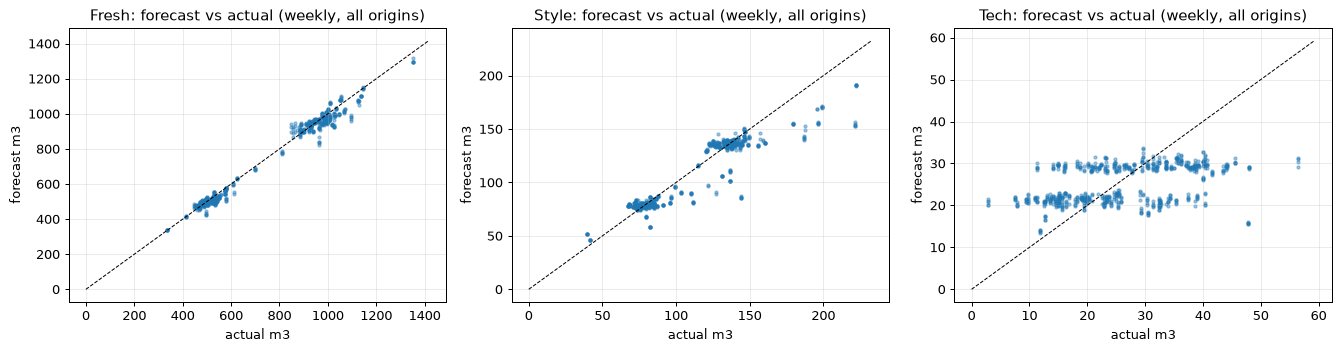

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for a, b in zip(axs, BRANDS):
    g = bt[bt.brand == b]; a.scatter(g.actual, g.pred, s=6, alpha=.4); lim = [0, g.actual.max() * 1.05]; a.plot(lim, lim, 'k--', lw=.8)
    a.set_title(f'{b}: forecast vs actual (weekly, all origins)'); a.set_xlabel('actual m3'); a.set_ylabel('forecast m3')
plt.tight_layout(); plt.savefig(FIGURES / '05b_pred_vs_actual.png'); plt.show()

**Reading.**
- The largest Fresh misses (10-15%) are the **Christmas weeks (ISO 51-52 of 2024 and the week after)** forecast from origins that had **never seen a Christmas**; this is a data-availability effect that disappears once a festival has been observed.
- **Short weeks are the weak spot:** with fewer than 6 operating days Fresh WAPE is 5.3% (bias -4.7%), Style 17.2% (bias -12.5%) and Tech 43% (bias -27%): the model removes the closed days a little too aggressively. Our real window has two such weeks (16 and 18). We tested catch-up features (05c, section 6) and they did not fix it.
- Style under-forecasts festival run-up weeks (bias -14%); Tech is noise-limited.
- Outside short weeks the forecasts are essentially unbiased (Fresh -1%, Tech -2%, Style -3%).

## 4. Forecast bands (empirical, calibrated out-of-time)
Bands are built from the ratio actual/forecast of past backtests: quantiles are estimated on the **first 17 origins** and their coverage is checked on the **last 17**, so the reported coverage is honest.

In [8]:
bt['ratio'] = bt.actual / bt.pred.clip(lower=1e-6)
first, last = sorted(bt.cut.unique())[:17], sorted(bt.cut.unique())[17:]
rows = []
for b in ('Fresh', 'Style'):
    cal_, test_ = bt[(bt.brand == b) & bt.cut.isin(first)], bt[(bt.brand == b) & bt.cut.isin(last)]
    lo, hi = cal_.ratio.quantile(.1), cal_.ratio.quantile(.9)
    cov = ((test_.actual >= test_.pred * lo) & (test_.actual <= test_.pred * hi)).mean()
    rows.append((b, round(lo, 3), round(hi, 3), round(cov, 3)))
bands = pd.DataFrame(rows, columns=['brand', 'ratio_p10', 'ratio_p90', 'coverage_on_held_out_origins (target 0.80)']); print(bands)
# Tech is count-noise dominated: additive bands in m3 per week (stable across depots)
tb = bt[bt.brand == 'Tech']; err = tb.actual - tb.pred
tcal, ttest = tb[tb.cut.isin(first)], tb[tb.cut.isin(last)]
elo, ehi = (tcal.actual - tcal.pred).quantile(.1), (tcal.actual - tcal.pred).quantile(.9)
print('Tech additive band (m3/week): [%.1f, %.1f], coverage %.3f' % (elo, ehi, ((ttest.actual - ttest.pred).between(elo, ehi)).mean()))
json.dump({'Fresh': bands.iloc[0, 1:3].tolist(), 'Style': bands.iloc[1, 1:3].tolist(), 'Tech_additive': [float(elo), float(ehi)]}, open(METRICS / 'task2a_band_params.json', 'w'))

   brand  ratio_p10  ratio_p90  coverage_on_held_out_origins (target 0.80)
0  Fresh      0.965      1.085                                       0.909
1  Style      0.918      1.198                                       0.812
Tech additive band (m3/week): [-12.0, 12.4], coverage 0.818


**Reading.** On origins that were *not* used to set them, coverage is 80% for Style, 82% for Tech, and 91% for Fresh (conservative, because the calibration origins had less history and larger errors). They are an extra deliverable for planners (vehicle/driver planning needs a range); the submission file contains the point forecast only.

## 5. Tested and rejected: a multiplicative correction for Style festival weeks
Style is under-forecast in run-up weeks (bias about -14%). Rule agreed with the team: a forecast adjustment is kept **only** if it improves the validation metric consistently. We calibrate a factor on one half of the origins and test it on the other half, in both directions.

In [9]:
g = bt[bt.brand == 'Style']; cuts = sorted(g.cut.unique()); h1, h2 = cuts[:17], cuts[17:]
wp = lambda d, p: (p - d.actual).abs().sum() / d.actual.sum()
rows = []
for name, cal_cuts, test_cuts in (('calibrate on early origins, test on later', h1, h2), ('calibrate on later origins, test on early', h2, h1)):
    c = g[g.cut.isin(cal_cuts) & (g.ramp > 0.4)]; t = g[g.cut.isin(test_cuts) & (g.ramp > 0.4)]; f = c.actual.sum() / c.pred.sum()
    rows.append((name, round(f, 3), len(t), round(wp(t, t.pred), 3), round(wp(t, t.pred * f), 3)))
pd.DataFrame(rows, columns=['split', 'factor', 'test run-up weeks', 'WAPE before', 'WAPE after'])

,split,factor,test run-up weeks,WAPE before,WAPE after
0,"calibrate on early origins, test on later",1.108,42,0.191,0.164
1,"calibrate on later origins, test on early",1.230,42,0.106,0.125


**Decision: rejected.** The correction helps in one direction and hurts in the other, and the factor is unstable (about 1.11 vs 1.23). The under-forecast is largest for origins that had seen few festivals and shrinks as history grows, so it is a data-availability effect, not a fixed bias; the final model, which has seen two seasons of each festival, should be closer to unbiased. We keep the unadjusted forecast and flag Style week 15 (New Year run-up) as the main residual risk.